<a href="https://www.kaggle.com/code/mariamogundeyi/czech-accidents-2016-2022-eda?scriptVersionId=314103419" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pylab as plt
import plotly.express as px

# Loading and reading the dataset

In [2]:
czech = pd.read_csv("/kaggle/input/datasets/pereprosov/road-accidents-in-the-czech-republic/road_accidents_czechia_2016_2022.csv")
czech.head().T

,0,1,2,3,4
id,60044184001.0,60044184009.0,60044184016.0,60044184022.0,60044184025.0
communication_kind,Highways,Highways,Highways,Highways,Highways
date,2018-01-01,2018-02-02,2018-03-01,2018-04-06,2018-04-18
time,1625.0,850.0,1959.0,2560.0,2560.0
accident_kind,collision with forest animals,collision with a fixed obstacle,collision with forest animals,collision with a fixed obstacle,collision with a fixed obstacle
crash_kind,not an option It is not a collision between mo...,not an option It is not a collision between mo...,not an option It is not a collision between mo...,not an option It is not a collision between mo...,not an option It is not a collision between mo...
fixed_precaution_kind,not an option not a collision with a fixed obs...,lever,not an option not a collision with a fixed obs...,lever,lever
injury,0.0,0.0,0.0,0.0,0.0
cause_of_accident,"forest game, domestic animals",driver of a motor vehicle,"forest game, domestic animals",driver of a motor vehicle,driver of a motor vehicle
alcohol,not detected,ne,not detected,not detected,not detected


# Checking the structure of the data (name, datatype and null values)

In [3]:
print(f"This dataset contains {czech.shape[0]} rows and {czech.shape[1]} columns")
for cols in czech:
    print(f"Column : {cols:35} || type : {str(czech[cols].dtype):7} || missing values % : {round(czech[cols].isnull().sum()/czech.shape[0]*100,2)}%")

This dataset contains 707027 rows and 46 columns
Column : id                                  || type : float64 || missing values % : 0.9%
Column : communication_kind                  || type : object  || missing values % : 0.9%
Column : date                                || type : object  || missing values % : 0.9%
Column : time                                || type : float64 || missing values % : 0.9%
Column : accident_kind                       || type : object  || missing values % : 0.9%
Column : crash_kind                          || type : object  || missing values % : 0.9%
Column : fixed_precaution_kind               || type : object  || missing values % : 0.9%
Column : injury                              || type : float64 || missing values % : 0.9%
Column : cause_of_accident                   || type : object  || missing values % : 0.9%
Column : alcohol                             || type : object  || missing values % : 0.96%
Column : main_cause_of_accident              || ty

# Feature Engineering

In [4]:
czech_copy = czech[['id', 'communication_kind', 'date', 'accident_kind', 'crash_kind', 'cause_of_accident', 'alcohol', 'main_cause_of_accident', 'killed_persons', 'severely_injured_persons', 'slightly_injured_persons', 'road_surface_type', 'condition_of_vehicle_surface', 'condition_of_communication', 'weather_conditions_at_the_time_of_accident', 'visibility', 'communication_accident_situation', 'traffic_control_at_the_time_of_an_accident', 'number_of_vehicles_involved', 'vehicle_type', 'year_of_manufacture', 'vehicle_owner', 'leakage_of_transported_materials', 'driver_condition', 'city', 'street', 'location']]
czech_copy

,id,communication_kind,date,accident_kind,crash_kind,cause_of_accident,alcohol,main_cause_of_accident,killed_persons,severely_injured_persons,...,traffic_control_at_the_time_of_an_accident,number_of_vehicles_involved,vehicle_type,year_of_manufacture,vehicle_owner,leakage_of_transported_materials,driver_condition,city,street,location
0,6.004418e+10,Highways,2018-01-01,collision with forest animals,not an option It is not a collision between mo...,"forest game, domestic animals",not detected,not caused by the driver,0.0,0.0,...,no traffic control method,1.0,passenger car without trailer,2010.0,private not used for profitable activities,none of the above,good no adverse circumstances were found,outside the municipality,NaN,outside the village
1,6.004418e+10,Highways,2018-02-02,collision with a fixed obstacle,not an option It is not a collision between mo...,driver of a motor vehicle,ne,the driver was not fully engaged in driving th...,0.0,0.0,...,no traffic control method,1.0,passenger car without trailer,2001.0,private not used for profitable activities,"there is a leak of fuel, oil, coolant, etc.",good no adverse circumstances were found,outside the municipality,NaN,outside the village
2,6.004418e+10,Highways,2018-03-01,collision with forest animals,not an option It is not a collision between mo...,"forest game, domestic animals",not detected,not caused by the driver,0.0,0.0,...,no traffic control method,1.0,passenger car without trailer,2015.0,"private organization (entrepreneur, s.r.o., v....",none of the above,good no adverse circumstances were found,outside the municipality,NaN,outside the village
3,6.004418e+10,Highways,2018-04-06,collision with a fixed obstacle,not an option It is not a collision between mo...,driver of a motor vehicle,not detected,the driver was not fully engaged in driving th...,0.0,0.0,...,no traffic control method,1.0,"undetected, driver drove off",-1.0,"undetected, driver drove off","undetected, driver drove off","undetected, driver drove off",outside the municipality,NaN,outside the village
4,6.004418e+10,Highways,2018-04-18,collision with a fixed obstacle,not an option It is not a collision between mo...,driver of a motor vehicle,not detected,the driver was not fully engaged in driving th...,0.0,0.0,...,no traffic control method,1.0,"undetected, driver drove off",-1.0,"undetected, driver drove off","undetected, driver drove off","undetected, driver drove off",outside the municipality,NaN,outside the village
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707022,1.801112e+11,class 2 roads,2022-11-11,collision with a fixed obstacle,not an option It is not a collision between mo...,driver of a motor vehicle,not detected,Failure to adapt speed to the technical road c...,0.0,0.0,...,no traffic control method,1.0,passenger car without trailer,2003.0,private not used for profitable activities,none of the above,NaN,Dobřeň,NaN,outside the village
707023,1.801112e+11,Class 1 roads,2022-11-18,crashes,not an option It is not a collision between mo...,driver of a motor vehicle,ne,failure to control the vehicle,0.0,0.0,...,no traffic control method,1.0,passenger car without trailer,2002.0,private not used for profitable activities,none of the above,good no adverse circumstances were found,Bělá Pod Bezdězem,NaN,outside the village
707024,1.811102e+11,3rd class roads,2022-10-24,collision with forest animals,not an option It is not a collision between mo...,"forest game, domestic animals",not detected,not caused by the driver,0.0,0.0,...,no traffic control method,1.0,passenger car without trailer,2012.0,private not used for profitable activities,none of the above,good no adverse circumstances were found,Svijany,NaN,outside the village
707025,1.902062e+11,local roads,2022-08-02,"collision with a vehicle parked, parked",not an option It is not a collision between mo...,driver of a motor vehicle,ne,avoidance without sufficient lateral clearance...,0.0,0.0,...,by a police officer

In [5]:
czech_copy.dropna(subset=['id', 'communication_kind', 'date', 'accident_kind', 'crash_kind', 'cause_of_accident', 'alcohol', 'main_cause_of_accident', 'killed_persons', 'severely_injured_persons', 'slightly_injured_persons', 'road_surface_type', 'condition_of_vehicle_surface', 'condition_of_communication', 'weather_conditions_at_the_time_of_accident', 'visibility', 'communication_accident_situation', 'traffic_control_at_the_time_of_an_accident', 'number_of_vehicles_involved', 'vehicle_type', 'year_of_manufacture', 'vehicle_owner', 'leakage_of_transported_materials', 'driver_condition', 'city', 'street', 'location'], inplace=True)

/tmp/ipykernel_16/3651290432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  czech_copy.dropna(subset=['id', 'communication_kind', 'date', 'accident_kind', 'crash_kind', 'cause_of_accident', 'alcohol', 'main_cause_of_accident', 'killed_persons', 'severely_injured_persons', 'slightly_injured_persons', 'road_surface_type', 'condition_of_vehicle_surface', 'condition_of_communication', 'weather_conditions_at_the_time_of_accident', 'visibility', 'communication_accident_situation', 'traffic_control_at_the_time_of_an_accident', 'number_of_vehicles_involved', 'vehicle_type', 'year_of_manufacture', 'vehicle_owner', 'leakage_of_transported_materials', 'driver_condition', 'city', 'street', 'location'], inplace=True)


In [6]:
# Converting features that are not in their correct datatype
czech_copy['id'] = czech_copy['id'].astype(str)
czech_copy['year_of_manufacture'] = czech_copy['year_of_manufacture'].astype(str)
czech_copy['date'] = pd.to_datetime(czech_copy['date'], format='%Y-%m-%d')
czech_copy['Year_Reported'] = czech_copy['date'].dt.year
czech_copy['Month_Reported'] = czech_copy['date'].dt.month
czech_copy['Day_Reported'] = czech_copy['date'].dt.day_name()
Month_dict = {1.0:'January', 2.0:'February', 3.0:'March', 4.0:'April', 5.0:'May', 6.0:'June', 7.0:'July', 8.0:'August', 9.0:'September', 10.0:'October', 11.0:'November', 12.0:'December'}
czech_copy['Month_Reported'] = czech_copy['Month_Reported'].apply(lambda x: Month_dict[x])

/tmp/ipykernel_16/1940245689.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  czech_copy['id'] = czech_copy['id'].astype(str)
/tmp/ipykernel_16/1940245689.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  czech_copy['year_of_manufacture'] = czech_copy['year_of_manufacture'].astype(str)
/tmp/ipykernel_16/1940245689.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

In [7]:
# Checking for duplicates
def columsn_with_duplicates(df, show_examples = False):
     dup_info = {}
     for col in df.columns:
        dup_mask = df[col].duplicated(keep=False)  # Mark all dup instances
        if dup_mask.any():
            unique_count = df[col].nunique()
            total_rows = len(df)
            dup_info[col] = {
                'unique_values': unique_count,
                'duplicate_percentage': (1 - unique_count / total_rows) * 100
            }
            if show_examples:
                examples = df[dup_mask][col].unique()[:5]  # First 5 dup values
                dup_info[col]['example_duplicates'] = examples.tolist()
        return dup_info

info = columsn_with_duplicates(czech_copy, show_examples=True)
print(info)

{}


# Data Visulaization
    # Accidents per year

/tmp/ipykernel_16/1206001008.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  czech_copy.set_index('date').resample('M').size().plot(label = "Trend of Accidents over the years", color = 'lightpink', ax = ax)
/tmp/ipykernel_16/1206001008.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  czech_copy.set_index('date').resample('M').size().rolling(window = 12).mean().plot(color = 'darkblue', linewidth = 4, label = '1 year rolling average', ax = ax)


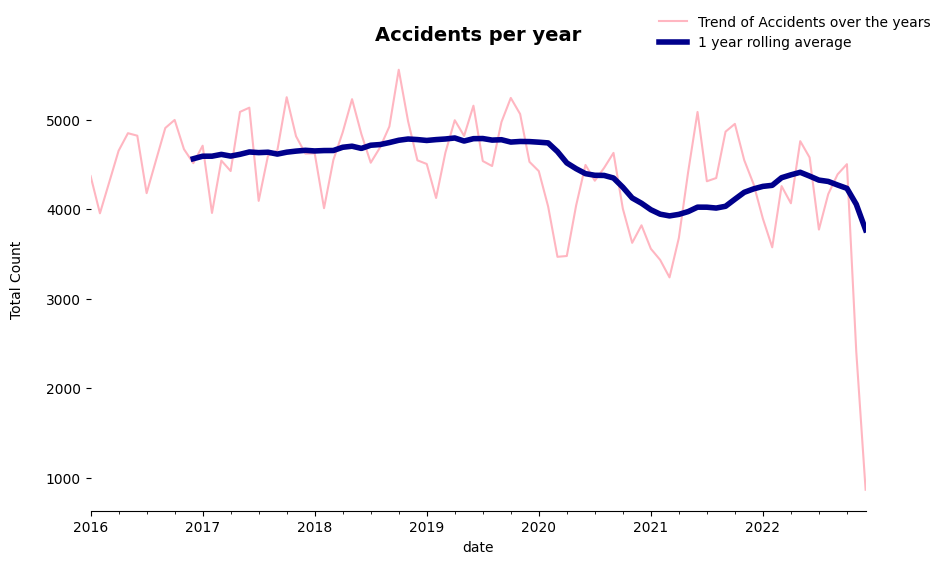

In [8]:
fig,ax = plt.subplots(figsize=(10,6))
czech_copy.set_index('date').resample('M').size().plot(label = "Trend of Accidents over the years", color = 'lightpink', ax = ax)
czech_copy.set_index('date').resample('M').size().rolling(window = 12).mean().plot(color = 'darkblue', linewidth = 4, label = '1 year rolling average', ax = ax)
ax.set_title("Accidents per year", fontsize = 14, fontweight = 'bold')
ax.set(ylabel = "Total Count\n")
ax.legend(bbox_to_anchor =(1.1,1.1), frameon = False)
sns.despine(ax = ax, top = True, right = True, left = True, bottom = False)

    #  Yearly Distribution of Accidents

/tmp/ipykernel_16/3363619241.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data = Year_Distribution, x = 'Year_Reported', y ='Count', palette='bwr', ax=ax)


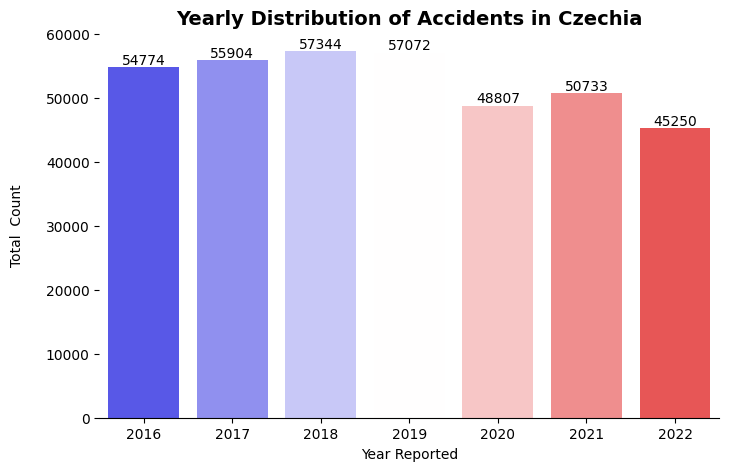

In [9]:
Year_Distribution = czech_copy.groupby('Year_Reported')['id'].size().reset_index(name = 'Count').sort_values(by = 'Year_Reported', ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.barplot(data = Year_Distribution, x = 'Year_Reported', y ='Count', palette='bwr', ax=ax)
ax.set_title("Yearly Distribution of Accidents in Czechia", fontsize = 14, fontweight = 'bold')
ax.set(xlabel = 'Year Reported', ylabel = 'Total  Count\n')
for bars in ax.containers:
    ax.bar_label(bars)
sns.despine(top=True, right=True, left=True, bottom=False) 

    # Distribution of accidents per month each year

In [10]:
Mnth_dict = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
Year_Month_Distribution = czech_copy.groupby(['Year_Reported', 'Month_Reported']).size()
Year_Month_Distribution = Year_Month_Distribution.rename_axis(['Year_Reported', 'Month_Reported']).unstack('Month_Reported').reindex(columns=Mnth_dict)
Year_Month_Distribution

Month_Reported,January,February,March,April,May,June,July,August,September,October,November,December
Year_Reported,,,,,,,,,,,,
2016,4371,3955,4304,4654,4850,4822,4180,4546,4908,4998,4671,4515
2017,4710,3959,4544,4427,5088,5135,4094,4599,4658,5252,4816,4622
2018,4625,4012,4551,4860,5230,4840,4520,4691,4925,5559,4984,4547
2019,4506,4126,4634,4995,4820,5157,4539,4483,4974,5244,5064,4530
2020,4426,4031,3469,3478,4043,4495,4319,4463,4630,4007,3625,3821
2021,3559,3434,3239,3680,4420,5087,4313,4349,4867,4954,4549,4282
2022,3895,3575,4259,4067,4761,4579,3773,4170,4390,4504,2410,867


In [11]:
def highlight_max_row(s):
    is_max = s == s.max()
    return ['background-color: slateblue; font-weight: bold' if v else '' for v in is_max]

# Apply the highlighting
styled = Year_Month_Distribution.style.apply(highlight_max_row, axis=1)

# Display it (in Jupyter notebook / lab / Colab)
styled

Month_Reported,January,February,March,April,May,June,July,August,September,October,November,December
Year_Reported,,,,,,,,,,,,
2016,4371,3955,4304,4654,4850,4822,4180,4546,4908,4998,4671,4515
2017,4710,3959,4544,4427,5088,5135,4094,4599,4658,5252,4816,4622
2018,4625,4012,4551,4860,5230,4840,4520,4691,4925,5559,4984,4547
2019,4506,4126,4634,4995,4820,5157,4539,4483,4974,5244,5064,4530
2020,4426,4031,3469,3478,4043,4495,4319,4463,4630,4007,3625,3821
2021,3559,3434,3239,3680,4420,5087,4313,4349,4867,4954,4549,4282
2022,3895,3575,4259,4067,4761,4579,3773,4170,4390,4504,2410,867


    # Yearly Summary of events

In [12]:
yearly_stats = czech_copy.groupby(['Year_Reported', 'Month_Reported']).agg({
        'killed_persons': 'sum',
        'severely_injured_persons': 'sum',
        'slightly_injured_persons':'sum',
        'number_of_vehicles_involved': 'sum'
}).rename(
    columns = {
    'killed_persons' :'Total_Killed_Persons',
    'severly_injured_persons' : 'Total_Severly_Inj_Persons',
    'slightly_injured_persons': 'Total_Slightly_Inj_Persons',
    'number_of_vehicles_involved': 'Total_Vehicles_Involved'
}).sort_values(by = ['Year_Reported', 'Month_Reported'], ascending=[False, True]).reset_index()


yearly_stats

,Year_Reported,Month_Reported,Total_Killed_Persons,severely_injured_persons,Total_Slightly_Inj_Persons,Total_Vehicles_Involved
0,2022,April,7.0,54.0,701.0,7289.0
1,2022,August,4.0,65.0,1004.0,7358.0
2,2022,December,1.0,12.0,95.0,1574.0
3,2022,February,4.0,41.0,518.0,6334.0
4,2022,January,7.0,49.0,585.0,6790.0
...,...,...,...,...,...,...
79,2016,March,9.0,80.0,693.0,7814.0
80,2016,May,7.0,109.0,972.0,8873.0
81,2016,November,11.0,82.0,853.0,8491.0
82,2016,October,14.0,91.0,882.0,9112.0


In [13]:
summary = []
for year in yearly_stats['Year_Reported'].unique():
    subset = yearly_stats[yearly_stats['Year_Reported'] == year]
    row = {'Year_Reported': year}
    for metric in ['Total_Killed_Persons', 'severely_injured_persons', 'Total_Slightly_Inj_Persons', 'Total_Vehicles_Involved']:
        worst = subset.loc[subset[metric].idxmax()]
        row.update({
            f'Months with the high stats ({metric})': worst['Month_Reported'],
            f'{metric}': int(worst[metric])
        })
    summary.append(row)

final = pd.DataFrame(summary).set_index('Year_Reported')

final.style\
  .background_gradient(cmap='OrRd', subset=final.select_dtypes('number').columns)\
  .format('{:,.0f}', subset=final.select_dtypes('number').columns)

,Months with the high stats (Total_Killed_Persons),Total_Killed_Persons,Months with the high stats (severely_injured_persons),severely_injured_persons,Months with the high stats (Total_Slightly_Inj_Persons),Total_Slightly_Inj_Persons,Months with the high stats (Total_Vehicles_Involved),Total_Vehicles_Involved
Year_Reported,,,,,,,,
2022,October,11,May,84,May,"1,091",May,"8,524"
2021,August,16,September,75,June,"1,144",June,"9,150"
2020,December,13,August,74,September,999,September,"8,354"
2019,September,13,June,100,June,"1,074",October,"9,565"
2018,December,13,August,108,May,"1,123",October,"10,108"
2017,June,16,May,104,June,"1,200",October,"9,578"
2016,December,17,June,115,June,"1,153",October,"9,112"


    # Common categories of accidents

/tmp/ipykernel_16/1170959688.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data = most_common_accident, x = 'Count', y = 'accident_kind', palette='bwr', ax = ax)


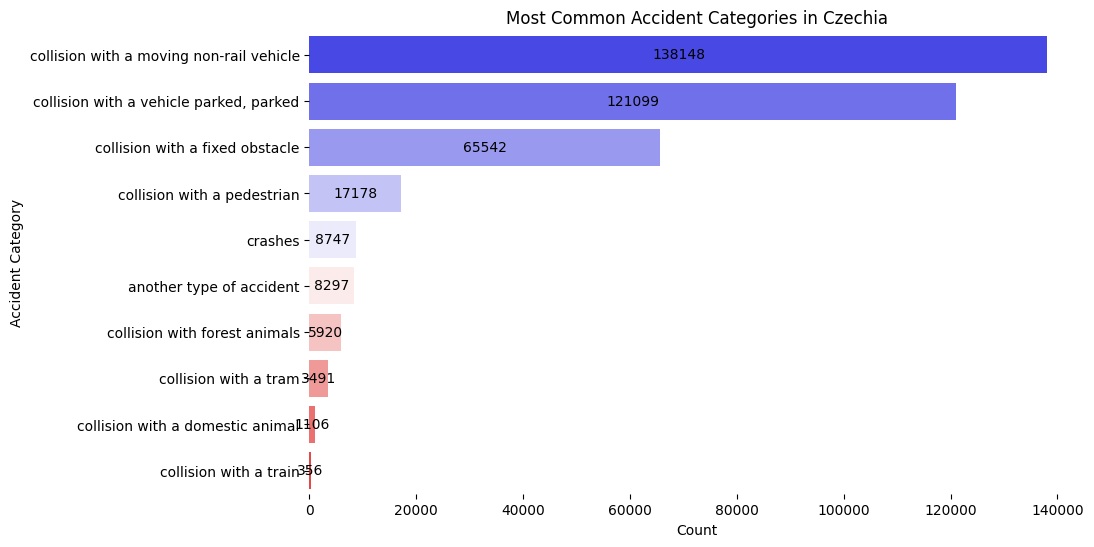

In [14]:
# Most common accident category 
most_common_accident = czech_copy.groupby('accident_kind')['id'].count().reset_index(name='Count').sort_values(by = 'Count', ascending=False)
fig,ax = plt.subplots(figsize = (10,6))
fig = sns.barplot(data = most_common_accident, x = 'Count', y = 'accident_kind', palette='bwr', ax = ax)
ax.set_title('Most Common Accident Categories in Czechia')
ax.set(ylabel='Accident Category', xlabel='Count')
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
sns.despine(top = True, right=True, bottom=True, left=True)
plt.show()

    # Common accident category each year

In [15]:
# Most common accident category each year
most_common_accident_each_year = czech_copy.groupby(['Year_Reported', 'accident_kind']).size().reset_index(name = 'Count')
most_common = (most_common_accident_each_year
               .loc[most_common_accident_each_year.groupby('Year_Reported')['Count'].idxmax()]
               .sort_values('Year_Reported', ascending=False)
               .reset_index(drop=True))

# Step 3: Add percentage of total accidents per year (optional but very useful)
total_per_year = most_common_accident_each_year.groupby('Year_Reported')['Count'].sum()
most_common['Percentage'] = (
    most_common['Count'] / most_common['Year_Reported'].map(total_per_year) * 100
).round(1)

# Step 4: Format nicely
most_common = most_common.rename(columns={
    'Year_Reported': 'Year',
    'accident_kind': 'Most Common Accident Kind',
    'Count': 'Number of Accidents',
    'Percentage': '% of Total Accidents in Year'
})

# Display the result
print(f"Most common accident kind per year:")
display(most_common)

Most common accident kind per year:


,Year,Most Common Accident Kind,Number of Accidents,% of Total Accidents in Year
0,2022,"collision with a vehicle parked, parked",16144,35.7
1,2021,"collision with a vehicle parked, parked",17696,34.9
2,2020,collision with a moving non-rail vehicle,17105,35.0
3,2019,collision with a moving non-rail vehicle,20908,36.6
4,2018,collision with a moving non-rail vehicle,22526,39.3
5,2017,collision with a moving non-rail vehicle,22885,40.9
6,2016,collision with a moving non-rail vehicle,22827,41.7


    # Most common type of crash

/tmp/ipykernel_16/897402779.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data = most_common_crash, x = 'Count', y = 'crash_kind', palette='bwr', ax = ax)


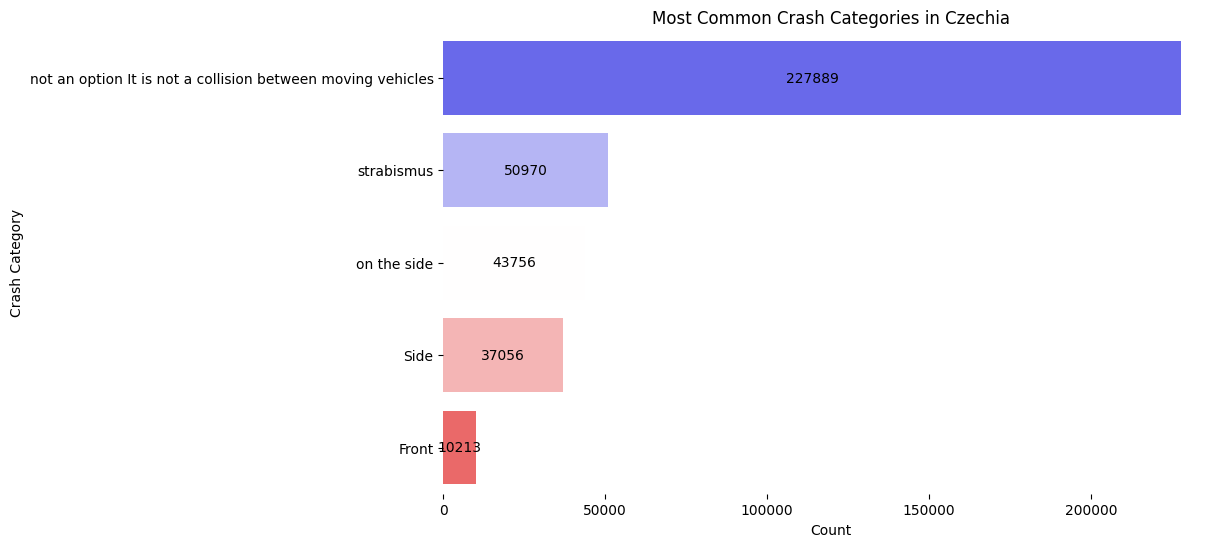

In [16]:
# most common crash kind
most_common_crash = czech_copy.groupby('crash_kind')['id'].count().reset_index(name='Count').sort_values(by = 'Count', ascending=False)
fig,ax = plt.subplots(figsize = (10,6))
fig = sns.barplot(data = most_common_crash, x = 'Count', y = 'crash_kind', palette='bwr', ax = ax)
ax.set_title('Most Common Crash Categories in Czechia')
ax.set(ylabel='Crash Category', xlabel='Count')
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
sns.despine(top = True, right=True, bottom=True, left=True)
plt.show()

    # Main causes of the collisions

/tmp/ipykernel_16/1903331551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data = main_casue_accident.head(10), y = 'Count', x = 'main_cause_of_accident', palette='bwr', ax = ax)


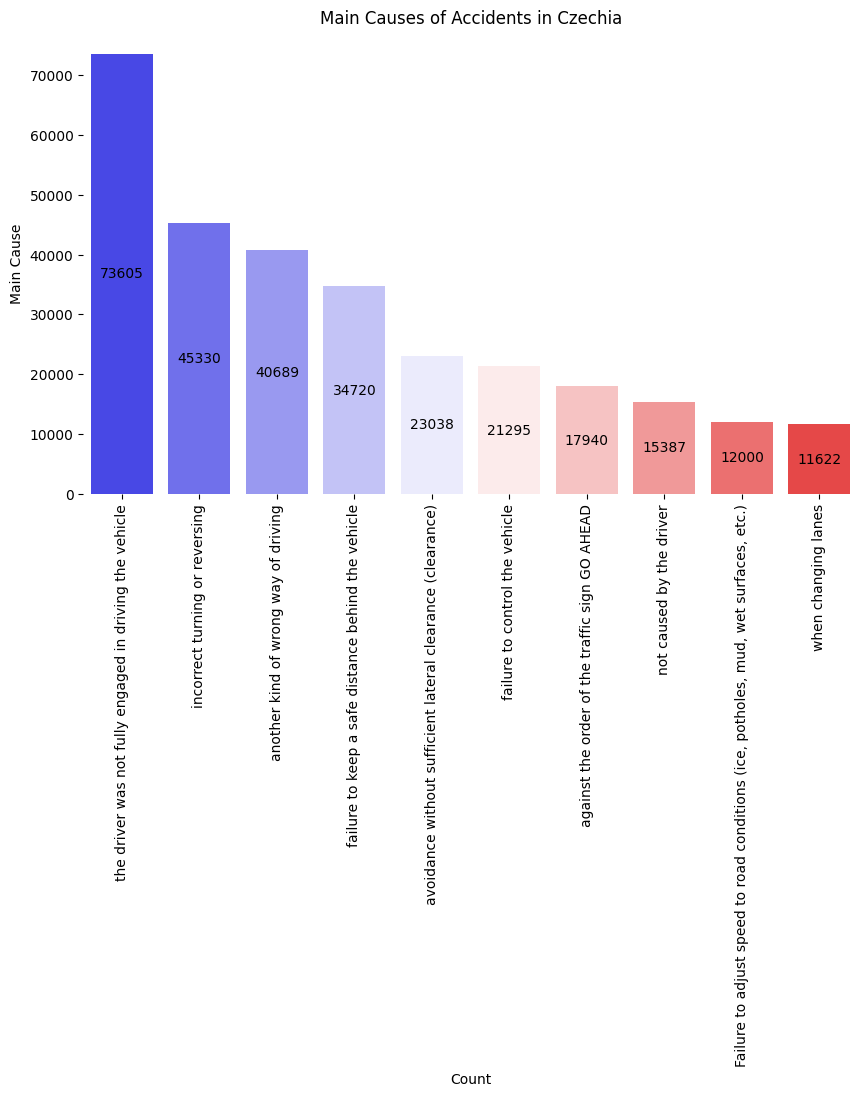

In [17]:
# Main cause of accidents
main_casue_accident = czech_copy.groupby('main_cause_of_accident')['id'].count().reset_index(name='Count').sort_values(by ='Count', ascending=False)
fig,ax = plt.subplots(figsize = (10,6))
fig = sns.barplot(data = main_casue_accident.head(10), y = 'Count', x = 'main_cause_of_accident', palette='bwr', ax = ax)
ax.set_title('Main Causes of Accidents in Czechia')
ax.set(ylabel='Main Cause', xlabel='Count')
ax.tick_params(axis='x', rotation=90)
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
sns.despine(top = True, right=True, bottom=True, left=True)
plt.show()

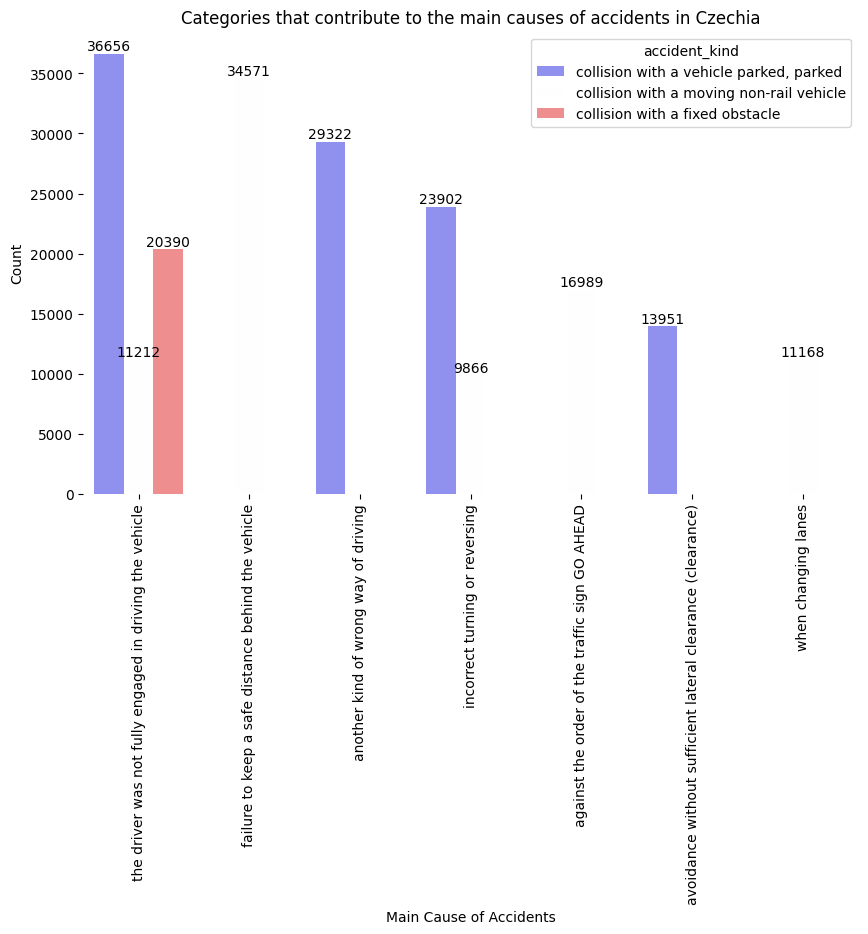

In [18]:
main_casue_accident_kind = czech_copy.groupby(['accident_kind', 'main_cause_of_accident'])['id'].count().reset_index(name='Count').sort_values(by ='Count', ascending=False)
fig,ax = plt.subplots(figsize = (10,6))
fig = sns.barplot(data = main_casue_accident_kind.head(10), y = 'Count', x = 'main_cause_of_accident',  hue= 'accident_kind',palette='bwr', ax = ax)
ax.set_title('Categories that contribute to the main causes of accidents in Czechia')
ax.set(ylabel='Count', xlabel='Main Cause of Accidents')
ax.tick_params(axis='x', rotation=90)
for bars in ax.containers:
    ax.bar_label(bars, label_type='edge')
sns.despine(top = True, right=True, bottom=True, left=True)
plt.show()

    # Summary of main causes of accidents

In [19]:
# Main cause of accidents each year
main_cause_each_year =  czech_copy.groupby(['Year_Reported', 'main_cause_of_accident']).size().reset_index(name = 'Count')
most_common_cause = (main_cause_each_year
               .loc[main_cause_each_year.groupby('Year_Reported')['Count'].idxmax()]
               .sort_values('Year_Reported', ascending=False)
               .reset_index(drop=True))

# Step 3: Add percentage of total accidents per year (optional but very useful)
total_per_year = main_cause_each_year.groupby('Year_Reported')['Count'].sum()
most_common_cause['Percentage'] = (
    most_common_cause['Count'] / most_common_cause['Year_Reported'].map(total_per_year) * 100
).round(1)

# Step 4: Format nicely
most_common_cause = most_common_cause.rename(columns={
    'Year_Reported': 'Year',
    'main_cause_of_accident': 'Main_Cause_of_Accidents',
    'Count': 'Number of Accidents',
    'Percentage': '% of Total Accidents in Year'
})

# Display the result
print(f"Main cause of accidents per year::")
display(most_common_cause)

Main cause of accidents per year::


,Year,Main_Cause_of_Accidents,Number of Accidents,% of Total Accidents in Year
0,2022,the driver was not fully engaged in driving th...,9210,20.4
1,2021,the driver was not fully engaged in driving th...,10237,20.2
2,2020,the driver was not fully engaged in driving th...,10001,20.5
3,2019,the driver was not fully engaged in driving th...,11430,20.0
4,2018,the driver was not fully engaged in driving th...,11162,19.5
5,2017,the driver was not fully engaged in driving th...,10789,19.3
6,2016,the driver was not fully engaged in driving th...,10776,19.7


    # Traffic control at the time of accidents

/tmp/ipykernel_16/2577039492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data = traffic_distribution, y = 'Count', x = 'traffic_control_at_the_time_of_an_accident', palette='bwr', ax = ax)


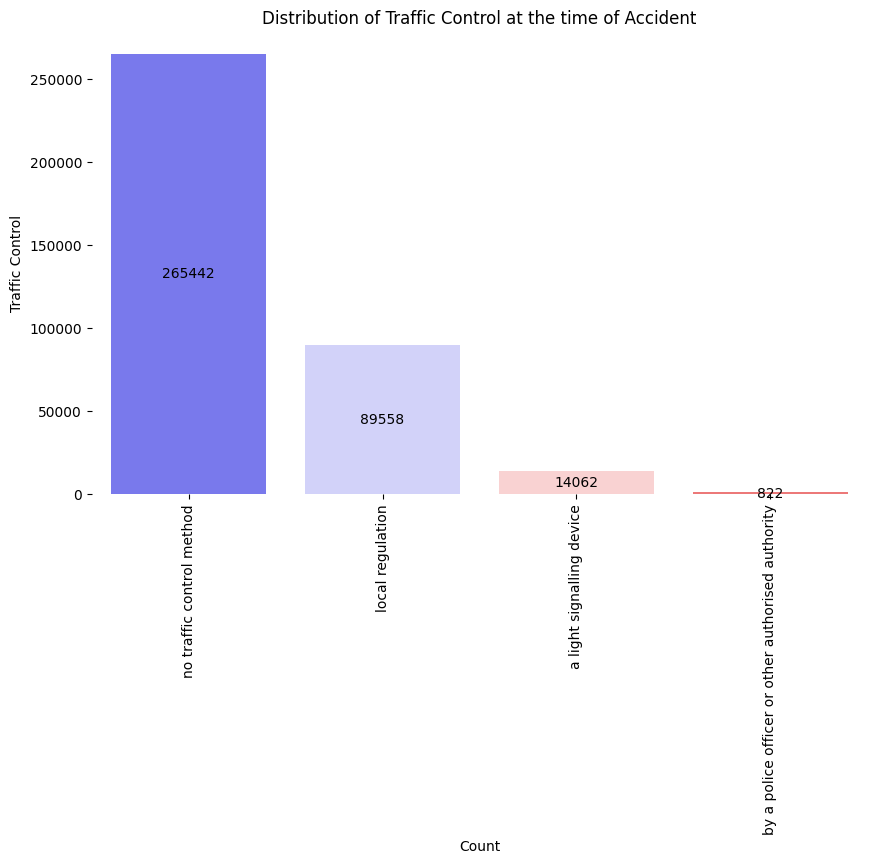

In [20]:
traffic_distribution = czech_copy.groupby('traffic_control_at_the_time_of_an_accident')['id'].size().reset_index(name='Count').sort_values(by='Count', ascending=False)
fig,ax = plt.subplots(figsize = (10,6))
fig = sns.barplot(data = traffic_distribution, y = 'Count', x = 'traffic_control_at_the_time_of_an_accident', palette='bwr', ax = ax)
ax.set_title('Distribution of Traffic Control at the time of Accident')
ax.set(ylabel='Traffic Control', xlabel='Count')
ax.tick_params(axis='x', rotation=90)
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
sns.despine(top = True, right=True, bottom=True, left=True)
plt.show()

In [21]:
czech_copy['traffic_control_at_the_time_of_an_accident'].value_counts()

traffic_control_at_the_time_of_an_accident
no traffic control method                            265442
local regulation                                      89558
a light signalling device                             14062
by a police officer or other authorised authority       822
Name: count, dtype: int64

In [22]:
traffic_control  = ['no traffic control method', 'local regulation', 'a light signalling device', 'by a police officer or other authorised authority']
main_cause_traffic = czech_copy.groupby(['main_cause_of_accident', 'traffic_control_at_the_time_of_an_accident']).size()
main_cause_traffic = main_cause_traffic.rename_axis(['main_cause_of_accident', 'traffic_control_at_the_time_of_an_accident']).unstack('traffic_control_at_the_time_of_an_accident').reindex(columns = traffic_control ).fillna(0)
main_cause_traffic['Total'] = main_cause_traffic.sum(axis = 1)
main_cause_traffic = main_cause_traffic.sort_values(by = 'Total', ascending=False)

print("Main Cause of Accident vs Traffic Control at the time of Accident :")
display(main_cause_traffic.style.format("{:.0f}").highlight_max(subset=['no traffic control method', 'local regulation', 'a light signalling device', 'by a police officer or other authorised authority'], color = 'lightblue'))

Main Cause of Accident vs Traffic Control at the time of Accident :


traffic_control_at_the_time_of_an_accident,no traffic control method,local regulation,a light signalling device,by a police officer or other authorised authority,Total
main_cause_of_accident,,,,,
the driver was not fully engaged in driving the vehicle,59570,12512,1351,172,73605
incorrect turning or reversing,38867,6151,221,91,45330
another kind of wrong way of driving,36035,4176,396,82,40689
failure to keep a safe distance behind the vehicle,26417,6171,2025,107,34720
avoidance without sufficient lateral clearance (clearance),19342,3129,503,64,23038
failure to control the vehicle,16482,4363,403,47,21295
against the order of the traffic sign GO AHEAD,7,17933,0,0,17940
not caused by the driver,12557,2233,568,29,15387
"Failure to adjust speed to road conditions (ice, potholes, mud, wet surfaces, etc.)",8636,3045,285,34,12000


    # Is Alcohol a contributing factor to these accidents

In [23]:
# Is Alcohol a contributing factor to these accidents
alcohol = ['ne', 'not detected', 'yes blood alcohol content 1.5‰ or more', 'yes blood alcohol content between 1.0 ‰ and 1.5 ‰', 'yes blood alcohol content between 0.24 ‰ and 0.5 ‰', 'yes blood alcohol content between 0.5 ‰ and 0.8 ‰', 'yes blood alcohol content from 0.8‰ to 1.0‰', 'yes blood alcohol content up to 0.24 ‰', 'Rejected']
alcohol_contributing = czech_copy.groupby(['main_cause_of_accident', 'alcohol']).size()
alcohol_contributing = alcohol_contributing.rename_axis(['main_cause_of_accident', 'alcohol']).unstack('alcohol').reindex(columns = alcohol ).fillna(0)
alcohol_contributing['Total'] = alcohol_contributing.sum(axis = 1)
alcohol_contributing = alcohol_contributing.sort_values(by = 'Total', ascending=False)

print("Is Alcohol a contributing factor to these accidents :")
display(alcohol_contributing.style.format("{:.0f}").highlight_max(subset=alcohol, color = 'coral'))

Is Alcohol a contributing factor to these accidents :


alcohol,ne,not detected,yes blood alcohol content 1.5‰ or more,yes blood alcohol content between 1.0 ‰ and 1.5 ‰,yes blood alcohol content between 0.24 ‰ and 0.5 ‰,yes blood alcohol content between 0.5 ‰ and 0.8 ‰,yes blood alcohol content from 0.8‰ to 1.0‰,yes blood alcohol content up to 0.24 ‰,Rejected,Total
main_cause_of_accident,,,,,,,,,,
the driver was not fully engaged in driving the vehicle,35758,35044,1702,374,187,164,122,121,133,73605
incorrect turning or reversing,26130,18090,594,154,113,87,48,64,50,45330
another kind of wrong way of driving,6771,33348,360,81,34,22,28,20,25,40689
failure to keep a safe distance behind the vehicle,32383,1747,247,74,92,43,40,54,40,34720
avoidance without sufficient lateral clearance (clearance),15749,6981,180,32,30,24,16,17,9,23038
failure to control the vehicle,7434,8472,3673,651,252,296,215,98,204,21295
against the order of the traffic sign GO AHEAD,16167,1302,161,59,83,54,31,42,41,17940
not caused by the driver,4343,10284,511,84,31,44,31,51,8,15387
"Failure to adjust speed to road conditions (ice, potholes, mud, wet surfaces, etc.)",10345,961,360,137,46,44,29,30,48,12000


    # The type of vehicles involved in these accidents

/tmp/ipykernel_16/914889192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data = vehicles_distr, y = 'Count', x = 'vehicle_type', palette='bwr', ax = ax)


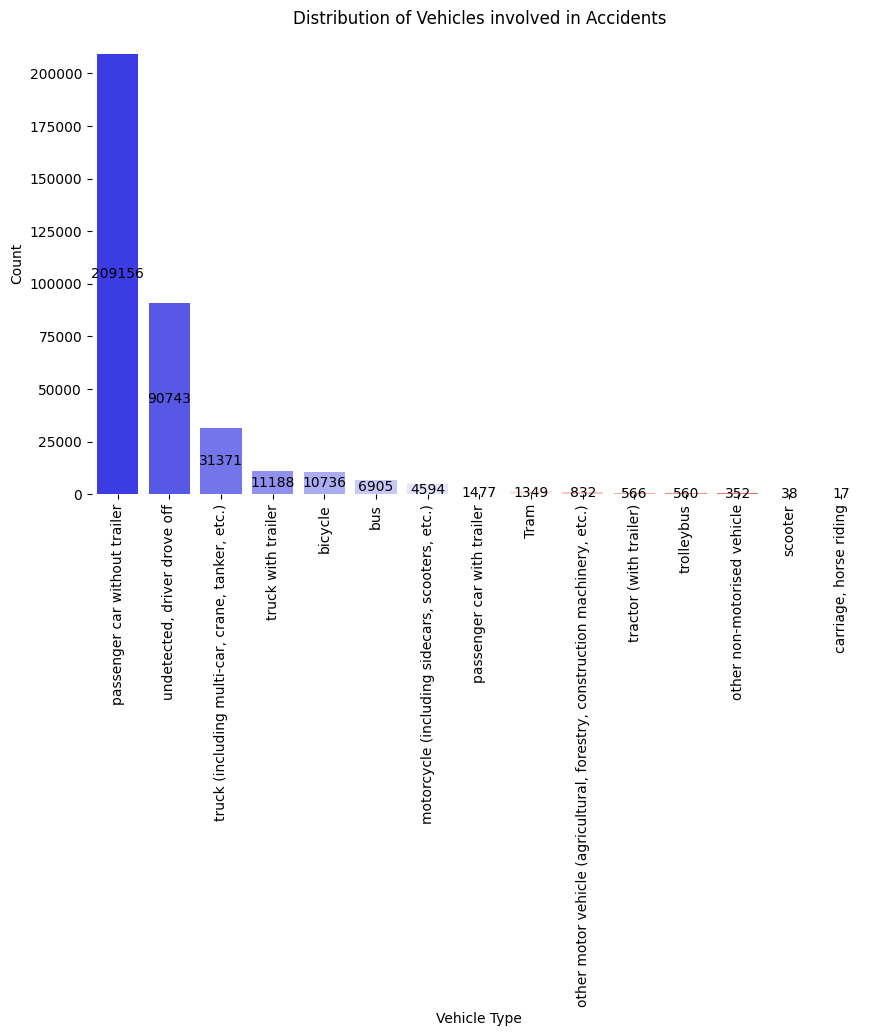

In [24]:
# Vehicles involved in these accidents 
vehicles_distr = czech_copy.groupby('vehicle_type')['id'].size().reset_index(name = 'Count').sort_values(by='Count', ascending=False)
fig,ax = plt.subplots(figsize = (10,6))
fig = sns.barplot(data = vehicles_distr, y = 'Count', x = 'vehicle_type', palette='bwr', ax = ax)
ax.set_title('Distribution of Vehicles involved in Accidents')
ax.set(ylabel='Count', xlabel='Vehicle Type')
ax.tick_params(axis='x', rotation=90)
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
sns.despine(top = True, right=True, bottom=True, left=True)
plt.show()

    # Catgeories of vehicle owners involved in these accidents

/tmp/ipykernel_16/3041545497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data = vehicles_owner_distr, y = 'Count', x = 'vehicle_owner', palette='bwr', ax = ax)


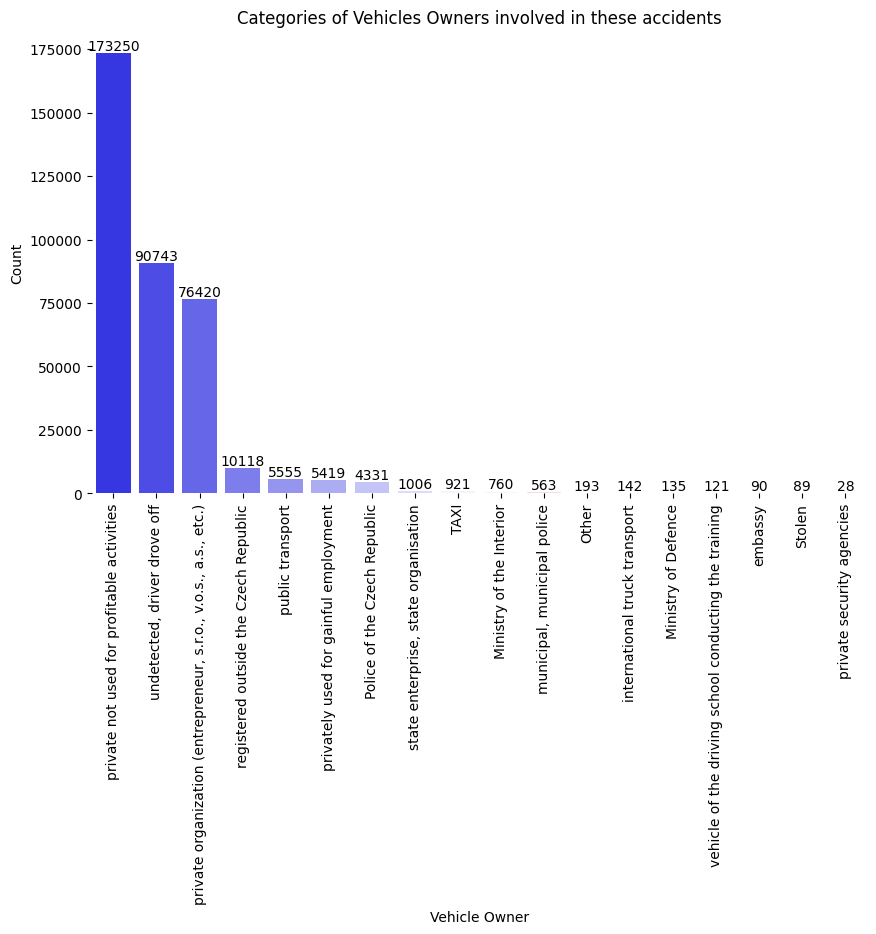

In [25]:
# Categories of vehicle owners involved in these accidents
vehicles_owner_distr = czech_copy.groupby('vehicle_owner')['id'].size().reset_index(name = 'Count').sort_values(by='Count', ascending=False)
fig,ax = plt.subplots(figsize = (10,6))
fig = sns.barplot(data = vehicles_owner_distr, y = 'Count', x = 'vehicle_owner', palette='bwr', ax = ax)
ax.set_title('Categories of Vehicles Owners involved in these accidents')
ax.set(ylabel='Count', xlabel='Vehicle Owner')
ax.tick_params(axis='x', rotation=90)
for bars in ax.containers:
    ax.bar_label(bars, label_type='edge')
sns.despine(top = True, right=True, bottom=True, left=True)
plt.show()

In [26]:
czech_copy['total_injuries'] = czech_copy['severely_injured_persons'] + czech_copy['slightly_injured_persons']
czech_copy['crash_severity'] = np.where(czech_copy['killed_persons'] > 1, 'Fatal', np.where(czech_copy['severely_injured_persons'] > 1, 'Severe', np.where(czech_copy['slightly_injured_persons']> 1, 'Slight', 'No Fatalities')))
czech_copy[['total_injuries', 'crash_severity']]

/tmp/ipykernel_16/1933597018.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  czech_copy['total_injuries'] = czech_copy['severely_injured_persons'] + czech_copy['slightly_injured_persons']
/tmp/ipykernel_16/1933597018.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  czech_copy['crash_severity'] = np.where(czech_copy['killed_persons'] > 1, 'Fatal', np.where(czech_copy['severely_injured_persons'] > 1, 'Severe', np.where(czech_copy['slightly_injured_persons']> 1, 'Slight', 'No Fatalities')))


,total_injuries,crash_severity
19,0.0,No Fatalities
20,0.0,No Fatalities
25,0.0,No Fatalities
29,1.0,No Fatalities
30,0.0,No Fatalities
...,...,...
706352,0.0,No Fatalities
706385,0.0,No Fatalities
706392,0.0,No Fatalities
706416,0.0,No Fatalities


In [27]:
czech_copy['Month'] = czech_copy['date'].dt.month
czech_copy['Day'] = czech_copy['date'].dt.day

/tmp/ipykernel_16/3069557898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  czech_copy['Month'] = czech_copy['date'].dt.month
/tmp/ipykernel_16/3069557898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  czech_copy['Day'] = czech_copy['date'].dt.day


# Machine Learning

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00         7
No Fatalities       0.98      1.00      0.99    108745
       Severe       0.00      0.00      0.00        46
       Slight       0.00      0.00      0.00      2168

     accuracy                           0.98    110966
    macro avg       0.24      0.25      0.25    110966
 weighted avg       0.96      0.98      0.97    110966



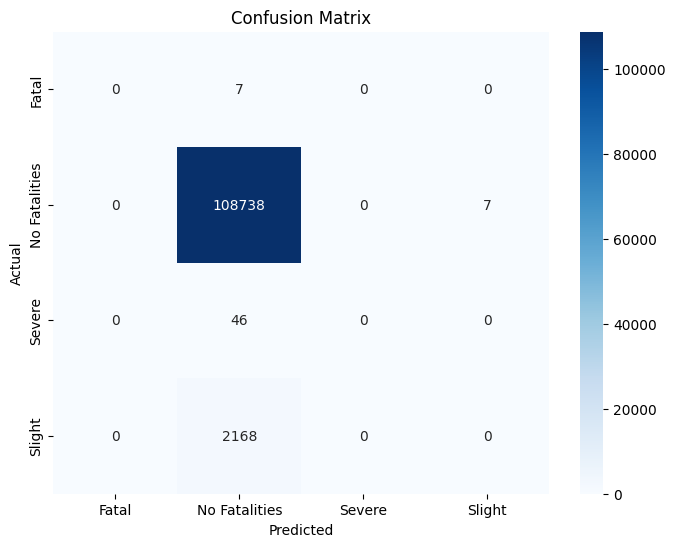

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
features  = ['number_of_vehicles_involved', 'Month', 'Day']
X = czech_copy[features]
y = czech_copy['crash_severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
# Trying the classfication method with the original dataset
czech['total_injuries'] = czech['severely_injured_persons'] + czech['slightly_injured_persons']
czech['crash_severity'] = np.where(czech['killed_persons'] > 0, 'Fatal', np.where(czech['severely_injured_persons'] > 0, 'Severe', np.where(czech['slightly_injured_persons']> 0, 'Slight', 'No Fatalities')))
czech[['total_injuries', 'crash_severity']]

,total_injuries,crash_severity
0,0.0,No Fatalities
1,0.0,No Fatalities
2,0.0,No Fatalities
3,0.0,No Fatalities
4,0.0,No Fatalities
...,...,...
707022,0.0,No Fatalities
707023,1.0,Slight
707024,0.0,No Fatalities
707025,0.0,No Fatalities


In [30]:
czech['date'] = pd.to_datetime(czech['date'], format='%Y-%m-%d')
czech['Month'] = czech['date'].dt.month
czech['Day'] = czech['date'].dt.day

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00       967
No Fatalities       0.80      1.00      0.89    170136
       Severe       0.00      0.00      0.00      3777
       Slight       0.29      0.00      0.00     37229

     accuracy                           0.80    212109
    macro avg       0.27      0.25      0.22    212109
 weighted avg       0.69      0.80      0.71    212109



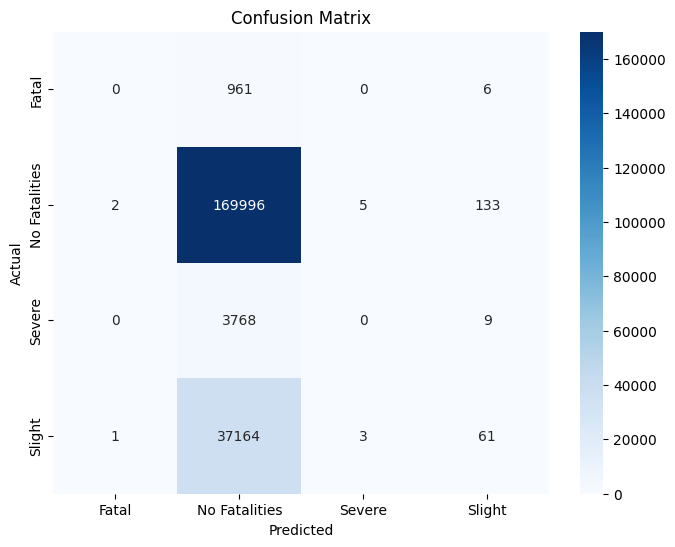

In [31]:
features  = ['number_of_vehicles_involved', 'Month', 'Day']
X = czech[features]
y = czech['crash_severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()